<h1 style="text-align:center;">3D models of TCRs recognizing an immunodominant Yellow Fever epitope unravel the structural basis of specificity and cross-reactivity</h1>

In [1]:
import os
import glob
import shutil
import pandas as pd
import numpy as np
import re

from Bio.PDB import PDBList
from pathlib import Path
from Bio.PDB import PDBParser, NeighborSearch, PDBIO, Superimposer, MMCIFParser
from Bio.SeqUtils import seq1

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
#import MDAnalysis as mda
#from MDAnalysis.coordinates.PDB import PDBWriter
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans

std_pal = sns.color_palette("deep")

# Colors

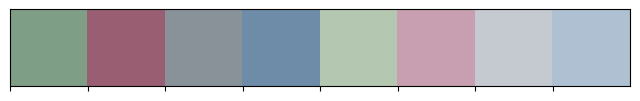

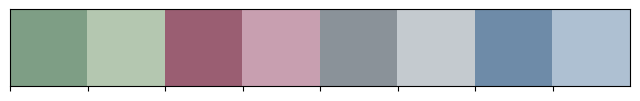

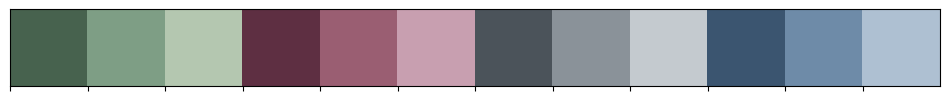

In [16]:
# ---- paper palette (two lightest shades per family) ----------------
# families: green · red · grey · blue ; (mid, light)
paper_pal_families = {
    'green': ['#7E9E85', '#B4C7B0'],
    'red':   ['#9A5E72', '#C89FB0'],
    'grey':  ['#8A9299', '#C4CACF'],
    'blue':  ['#6E8BA8', '#AEC0D2'],
}

# palette 1 — ordered by level: all darker, then all lighter
paper_pal_level = [paper_pal_families[f][lvl]
                   for lvl in range(2)
                   for f in paper_pal_families]
# ['#7E9E85','#9A5E72','#8A9299','#6E8BA8',   # darker of the two
#  '#B4C7B0','#C89FB0','#C4CACF','#AEC0D2']   # lighter

# palette 2 — ordered by color: each family's two shades together
paper_pal_color = [c for f in paper_pal_families for c in paper_pal_families[f]]
# ['#7E9E85','#B4C7B0','#9A5E72','#C89FB0',
#  '#8A9299','#C4CACF','#6E8BA8','#AEC0D2']

sns.palplot(paper_pal_level)
sns.palplot(paper_pal_color)

paper_pal_families3 = {
    'green': ['#47624E', '#7E9E85', '#B4C7B0'],
    'red':   ['#5E2F42', '#9A5E72', '#C89FB0'],
    'grey':  ['#4B535A', '#8A9299', '#C4CACF'],   # cool slate-grey
    'blue':  ['#3B5570', '#6E8BA8', '#AEC0D2'],
}

# by color, dark -> light within each family (12 colors)
paper_pal_color3 = [c for f in paper_pal_families3 for c in paper_pal_families3[f]]
# ['#47624E','#7E9E85','#B4C7B0',   # green
#  '#5E2F42','#9A5E72','#C89FB0',   # red
#  '#4B535A','#8A9299','#C4CACF',   # grey
#  '#3B5570','#6E8BA8','#AEC0D2']   # blue

sns.palplot(paper_pal_color3)


# Identification A0201_LLWNGPMAV:TCR binding modes

## Exclude MAIT cells

In [14]:
topdir = 'data_julien'
batch = 'LAU5013/YF_LAU5013_sc_WT'

csv_file = glob.glob(f'{topdir}/{batch}/YF_LAU5013_sc_WT_AF3_anno.csv')[0]
df = pd.read_csv(csv_file)

mait_mask = (df['TRAV'] == 'TRAV1-2') & (df['TRAJ'].isin(['TRAJ33', 'TRAJ20', 'TRAJ12']))
df.loc[mait_mask, 'TEMPOproblem'] = 'MAIT'

df.to_csv('YF_LAU5013_sc_WT_AF3_anno.csv', index=False)

## CDR conformational descriptor

Each model is superposed onto the **MHC** (Cα of chain A), placing all TCRs in a
common MHC reference frame so the descriptor captures where each loop sits over
the groove, not just its internal shape.

For every model we locate the six CDR loops by sequence match and extract their
Cα coordinates. Because loops differ in length, each loop's Cα trace is treated
as a 3D curve and **resampled to a fixed number of points evenly spaced along its
arc length** (target = median loop length per CDR across all TCRs). This keeps the
full loop — including the apex — and makes point *k* the same fractional position
along the loop in every TCR, so loops of different length become comparable.

The resampled coordinates of all six CDRs are concatenated into one vector per
TCR (`coord_matrix.pkl`), which is then used for PCA / UMAP of the conformational
landscape.

In [23]:
# AF models for YF-epitope  — arc-length resampled CDR descriptor
from scipy.interpolate import interp1d  # not strictly needed; np.interp used below

def extract_cdr_coords(pdb_path, cdr_dict, chain_map={"TRA":"A","TRB":"B"}):
    """Extract CA coordinates of each CDR by matching its sequence in the chain."""
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("pdb", pdb_path)
    cdr_coords = {}
    for chain_label, chain_id in chain_map.items():
        chain_obj = structure[0][chain_id]
        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        seq = "".join([seq1(res.get_resname()) for res in residues])
        cdr_coords[chain_label] = {}
        for i, cdr_key in enumerate([f"CDR1{chain_label[-1]}", f"CDR2{chain_label[-1]}", f"CDR3{chain_label[-1]}"], 1):
            cdr_seq = cdr_dict[cdr_key].upper()
            L = len(cdr_seq)
            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: CDR {cdr_key} sequence not found in chain {chain_id} of {pdb_path}")
                return None
            coords = np.array([res["CA"].get_coord() for res in residues[start_idx:start_idx + L]])
            cdr_coords[chain_label][f"cdr{i}"] = coords
    return cdr_coords


def resample_loop(coords, n_points):
    """Resample a CA trace (n,3) to n_points evenly spaced along its arc length."""
    coords = np.asarray(coords, float)
    if len(coords) == n_points:
        return coords
    if len(coords) == 1:
        return np.repeat(coords, n_points, axis=0)
    d = np.r_[0, np.cumsum(np.linalg.norm(np.diff(coords, axis=0), axis=1))]
    if d[-1] == 0:                                   # degenerate: all points identical
        return np.repeat(coords[:1], n_points, axis=0)
    u = d / d[-1]                                    # cumulative arc length, 0..1
    ut = np.linspace(0, 1, n_points)
    return np.column_stack([np.interp(ut, u, coords[:, k]) for k in range(3)])


def build_coord_matrix(cdr_coord_dict, target_lengths):
    """Flatten resampled CDR1/2/3 (both chains) into one vector per TCR."""
    coord_matrix = []
    for tcr, chains in cdr_coord_dict.items():
        vec = []
        for chain, cdrs in chains.items():
            for cdr_name in ["cdr1", "cdr2", "cdr3"]:
                N = target_lengths[chain][cdr_name]
                vec.extend(resample_loop(cdrs[cdr_name], N).flatten())
        coord_matrix.append(vec)
    return np.array(coord_matrix)


# ---- extract CDR coordinates for every model -------------------------------
cdr_coord_dict = {}

topdir = 'data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

for batch in batches:
    batch_short = batch.split('/')[0]
    cdr_coord_dict[batch_short] = {}

    # CDRs annotated with tcr_cdr_annotation.R
    csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
    df = pd.read_csv(csv_file)
    df = df[df["TEMPOproblem"].isna()]

    pdbs = glob.glob(f'{topdir}/{batch}/model_pdb_align_exp/*.pdb')
    pdbs.sort()
    pdbs = [p for p in pdbs if os.path.basename(p.split('.')[0]) in df['id'].values]

    for pdb_file in pdbs:
        pdb_id = os.path.basename(pdb_file.split('.')[0])
        row = df[df["id"] == pdb_id]
        cdr_dict = {cdr: str(row[cdr].values[0]).upper() for cdr in
                    ["cdr1_TRA","cdr2_TRA","cdr3_TRA","cdr1_TRB","cdr2_TRB","cdr3_TRB"]}
        cdr_dict = {
            k.replace("cdr", "CDR").replace("_TRA", "A").replace("_TRB", "B"): v
            for k, v in cdr_dict.items()
        }
        cdr_coords = extract_cdr_coords(pdb_file, cdr_dict, chain_map={"TRA":"B","TRB":"C"})
        if cdr_coords is not None:
            cdr_coord_dict[batch_short][pdb_id] = cdr_coords


# ---- target lengths = MEDIAN loop length across all TCRs -------------------
target_cdr_lengths = {}
for chain_label in ["TRA", "TRB"]:
    target_cdr_lengths[chain_label] = {}
    for cdr_name in ["cdr1", "cdr2", "cdr3"]:
        all_lengths = [chains[chain_label][cdr_name].shape[0]
                       for pdbs in cdr_coord_dict.values()
                       for chains in pdbs.values()]
        target_cdr_lengths[chain_label][cdr_name] = int(np.round(np.median(all_lengths)))

print("target (median) CDR lengths:", target_cdr_lengths)


# ---- build coordinate matrix ----------------------------------------------
lst = []
for batch, batch_dict in cdr_coord_dict.items():
    coord_matrix = build_coord_matrix(batch_dict, target_cdr_lengths)
    df = pd.DataFrame(coord_matrix)
    df.insert(0, 'batch', batch)
    df.insert(0, 'PDB', list(batch_dict.keys()))
    lst.append(df)

df = pd.concat(lst)

# ---- annotate germline segments -------------------------------------------
batches_anno = {
    'LAU5013' : 'data_julien/LAU5013/YF_LAU5013_sc_WT/YF_LAU5013_sc_WT_AF3_anno.csv',
    'Public_Data' : 'data_julien/Public_Data/YF_public_pairedData_20251010/YF_public_pairedData_20251010_AF3_anno.csv'
}

lst = []
for batch, csv_file in batches_anno.items():
    df_anno = pd.read_csv(csv_file)
    df_anno = df_anno.rename(columns={'id':'PDB'})
    df_anno = df_anno[['PDB', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB', 'AF3_iptm_pair_mean']]
    df_anno['batch'] = batch
    lst.append(df_anno)

anno = pd.concat(lst)

df_merged = pd.merge(anno, df, on=['PDB', 'batch'])
df_merged.to_pickle('coord_matrix.pkl')

# saved for reference (replaces the old min_cdr_lengths.pkl)
with open("target_cdr_lengths.pkl", "wb") as f:
    pickle.dump(target_cdr_lengths, f)

target (median) CDR lengths: {'TRA': {'cdr1': 6, 'cdr2': 6, 'cdr3': 10}, 'TRB': {'cdr1': 5, 'cdr2': 6, 'cdr3': 14}}


## Perform PCA

         PDB        batch      TRAV        PC1        PC2       tmp
0    tcr0001      LAU5013  TRAV12-2   0.625957   4.714019  TRAV12-2
1    tcr0005      LAU5013  TRAV12-2   0.779552  -3.061647  TRAV12-2
2    tcr0010      LAU5013  TRAV12-1  -5.670480   6.548908  TRAV12-1
3    tcr0014      LAU5013  TRAV12-2  -2.875493   1.071525  TRAV12-2
4    tcr0018      LAU5013  TRAV12-2   4.312536  -3.695602  TRAV12-2
..       ...          ...       ...        ...        ...       ...
511  tcr0384  Public_Data    TRAV17  -8.906055  -9.528403     other
512  tcr0385  Public_Data  TRAV12-2   0.297821  12.410889  TRAV12-2
513  tcr0386  Public_Data    TRAV27  -7.847559   1.722416    TRAV27
514  tcr0387  Public_Data  TRAV12-2  12.104648  -2.883792  TRAV12-2
515  tcr0388  Public_Data  TRAV12-2   0.918755   1.412342  TRAV12-2

[516 rows x 6 columns]
         PDB        batch      TRAV        PC1        PC2       tmp
123  tcr1145      LAU5013     TRAV4 -53.239059 -29.257580     other
377  tcr0176  Public_Dat

/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_50438/1624705821.py:19: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.scatterplot(df_pca, x='PC1', y='PC2', hue='batch', ax=ax, edgecolor='black', s=15, palette=paper_pal_level)
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_50438/1624705821.py:36: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.scatterplot(df_pca, x='PC1', y='PC2', hue='tmp', ax=ax, edgecolor='black', s=15, palette=paper_pal_level)


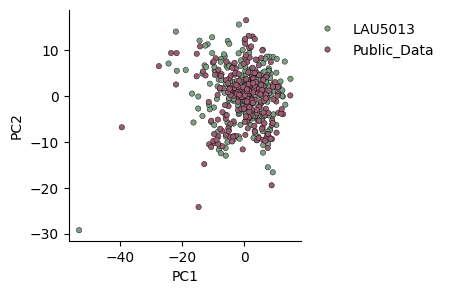

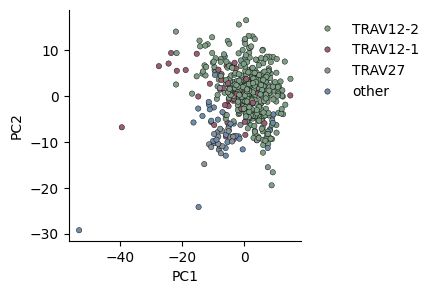

In [17]:
# load coordinate matrix
df = pd.read_pickle('coord_matrix.pkl')
df = df[df['AF3_iptm_pair_mean'] > 0.8]

coord_matrix = df.iloc[:,9:].to_numpy()

pca = PCA(n_components=2)
pcs = pca.fit_transform(coord_matrix)

df_pca = pd.DataFrame()
df_pca['PC1'] = pcs[:,0]
df_pca['PC2'] = pcs[:,1]
df_pca['PDB'] = df['PDB'].values
df_pca["PDB"] = df_pca["PDB"].apply(lambda x: os.path.basename(x).split('.')[0])
df_pca['batch'] = df['batch'].values

fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df_pca, x='PC1', y='PC2', hue='batch', ax=ax, edgecolor='black', s=15, palette=paper_pal_level)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()

# annotate by TRAV
df_pca = df[['PDB', 'batch', 'TRAV']].copy().reset_index(drop=True)
df_pca['PC1'] = pcs[:, 0]
df_pca['PC2'] = pcs[:, 1]
df_pca['PDB'] = df_pca['PDB'].apply(lambda x: os.path.basename(x).split('.')[0])

lst = ['TRAV12-2', 'TRAV12-1', 'TRAV27']
df_pca['tmp'] = np.where(df_pca['TRAV'].isin(lst), df_pca['TRAV'], 'other')
order = ['TRAV12-2', 'TRAV12-1', 'TRAV27', 'other']
df_pca['tmp'] = pd.Categorical(df_pca['tmp'], categories=order, ordered=True)

fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df_pca, x='PC1', y='PC2', hue='tmp', ax=ax, edgecolor='black', s=15, palette=paper_pal_level)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()

print(df_pca)
print(df_pca[df_pca['PC1'] < -30])

## Hirarchical clustering in PCA space

/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_50438/755531060.py:26: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.scatterplot(df_pca, x='PC1', y='PC2', hue='cluster', ax=ax,


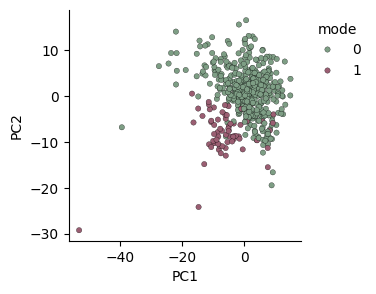

In [12]:
from sklearn.cluster import AgglomerativeClustering

# --- load & filter (same as your PCA cell) ---
df = pd.read_pickle('coord_matrix.pkl')
df = df[df['AF3_iptm_pair_mean'] > 0.8].copy()
coord_matrix = df.iloc[:, 9:].to_numpy()

# --- PCA: 6 components for clustering, first 2 for display ---
pca = PCA(n_components=6, random_state=0)
pcs = pca.fit_transform(coord_matrix)

# --- Ward clustering on the 6 PCs ---
labels = AgglomerativeClustering(n_clusters=2, linkage='ward').fit_predict(pcs)

# --- assemble plotting frame ---
df_pca = pd.DataFrame({
    'PC1': pcs[:, 0],
    'PC2': pcs[:, 1],
    'cluster': labels.astype(str),
    'PDB': [os.path.basename(p).split('.')[0] for p in df['PDB'].values],
    'batch': df['batch'].values,
    'TRAV': df['TRAV'].values,
})

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.scatterplot(df_pca, x='PC1', y='PC2', hue='cluster', ax=ax,
                edgecolor='black', linewidth=0.2, s=15, palette=paper_pal_level)
ax.legend(title='mode', bbox_to_anchor=(1, 1), frameon=False, loc='upper left')
sns.despine()

## Hyperparameters

In [19]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

df = pd.read_pickle('coord_matrix.pkl')
df = df[df['AF3_iptm_pair_mean'] > 0.8]
X = df.iloc[:, 9:].to_numpy()

N_PC = 6
pca_full = PCA().fit(X)
cum = np.cumsum(pca_full.explained_variance_ratio_)
Z = PCA(n_components=N_PC, random_state=0).fit_transform(X)   # space used for clustering

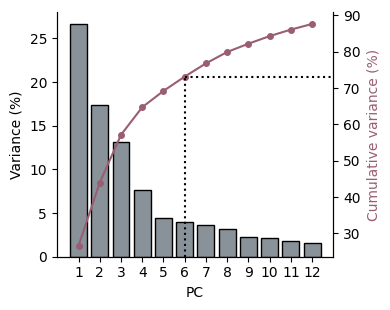

In [34]:
fig, ax = plt.subplots(figsize=(4, 3.2))
ax.bar(range(1, 13), pca_full.explained_variance_ratio_[:12] * 100,
       color='#8A9299', edgecolor='k')
ax2 = ax.twinx()
ax2.plot(range(1, 13), cum[:12] * 100, '-o', color='#9A5E72', ms=4)

ycut = cum[N_PC - 1] * 100
xmax = ax.get_xlim()[1]
ymin = ax2.get_ylim()[0]

# vertical line stops at the cumulative level; horizontal line runs from there to the right axis
ax2.vlines(N_PC, ymin, ycut, ls=':', color='black')
ax2.hlines(ycut, N_PC, xmax, ls=':', color='black')

ax.set_xlim(right=xmax)
ax2.set_ylim(bottom=ymin)   # keep the vertical line flush with the x-axis

ax.set_xlabel('PC')
ax.set_ylabel('Variance (%)')
ax2.set_ylabel('Cumulative variance (%)', color='#9A5E72')
ax.set_xticks(range(1, 13))
sns.despine(right=False)
plt.tight_layout()

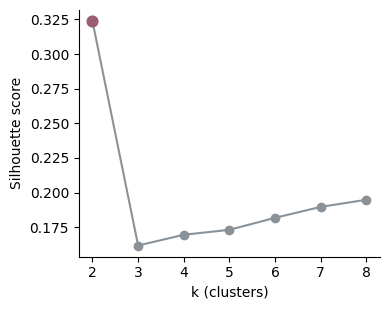

In [28]:
ks = range(2, 9)
sils = [silhouette_score(Z, AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(Z))
        for k in ks]

fig, ax = plt.subplots(figsize=(4, 3.2))
ax.plot(list(ks), sils, '-o', color='#8A9299')
ax.scatter([2], [sils[0]], color='#9A5E72', zorder=5, s=60)   # highlight k=2
ax.set_xlabel('k (clusters)')
ax.set_ylabel('Silhouette score')
sns.despine()
plt.tight_layout()

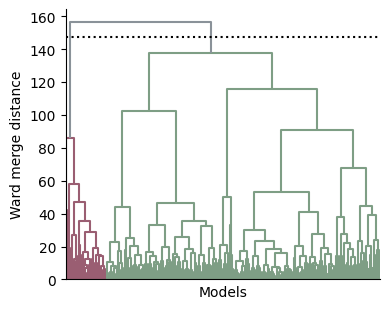

In [37]:
from scipy.cluster.hierarchy import set_link_color_palette

L = linkage(Z, method='ward')
set_link_color_palette(['#9A5E72', '#7E9E85'])   # the two clusters (was orange, green)

fig, ax = plt.subplots(figsize=(4, 3.2))
dendrogram(L, ax=ax, no_labels=True,
           color_threshold=L[-1, 2] * 0.99,
           above_threshold_color='#8A9299')       # links above the cut (was blue)
ax.axhline(L[-2, 2] + (L[-1, 2] - L[-2, 2]) / 2, ls=':', color='black')
ax.set_xlabel('Models')
ax.set_ylabel('Ward merge distance')
sns.despine()
plt.tight_layout()

set_link_color_palette(None)   # reset so other dendrograms aren't affected

## Project AF3-models (YF-epitope) into experimental space

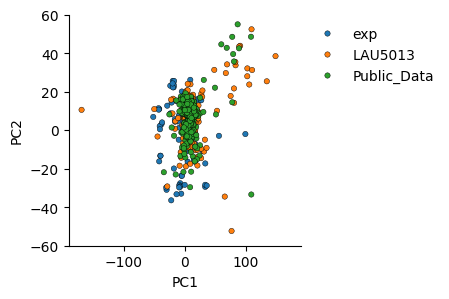

In [78]:
df = pd.read_pickle('coord_matrix.pkl')

# learn space based on experimental structures
df_exp = df[df['batch'] == 'exp']
coord_matrix_exp = df_exp.iloc[:,8:].to_numpy()
pca = PCA(n_components=2)
pcs_exp = pca.fit_transform(coord_matrix_exp)

# project AF3-models (YF-epitope) into experimental space
df_af3 = df[df['batch'] != 'exp']
coord_matrix_af3 = df_af3.iloc[:,8:].to_numpy()
pcs_af3 = pca.transform(coord_matrix_af3)

pcs = np.concatenate([pcs_exp, pcs_af3])

df_pca = pd.DataFrame()
df_pca['PC1'] = pcs[:,0]
df_pca['PC2'] = pcs[:,1]
df_pca['PDB'] = df['PDB'].values
df_pca["PDB"] = df_pca["PDB"].apply(lambda x: os.path.basename(x).split('.')[0])
df_pca['batch'] = df['batch'].values

fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df_pca, x='PC1', y='PC2', hue='batch', ax=ax, edgecolor='black', s=15)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
ax.set_xlim(-190, 190)
ax.set_ylim(-60, 60)
sns.despine()



## Filter AF3 models by ipTM

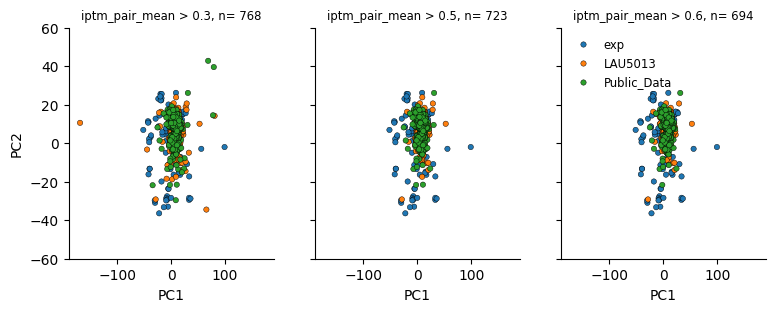

In [ ]:
# look at different plddt thresholds
topdir = 'data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

df = pd.read_pickle('coord_matrix.pkl')

fig, axes = plt.subplots(1, 3, figsize=(3*3,3), sharey=True)
thresholds = [0.3, 0.5, 0.6]
filter_threshold = 0.5

for cnt, threshold in enumerate(thresholds):
    ax = axes[cnt]

    lst=[]
    for batch in batches:
        batch_short = batch.split('/')[0]
        csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
        df_af3_conf = pd.read_csv(csv_file)
        df_af3_conf = df_af3_conf[df_af3_conf["TEMPOproblem"].isna()]
        sel_ids = df_af3_conf.loc[df_af3_conf['AF3_iptm_pair_mean'] > threshold, 'id'].tolist()
        tmp = df[(df['batch'] == batch_short) & (df['PDB'].isin(sel_ids))]
        lst.append(tmp)

    df_af3 = pd.concat(lst)

    # learn space based on experimental structures
    df_exp = df[df['batch'] == 'exp']
    coord_matrix_exp = df_exp.iloc[:,8:].to_numpy()
    pca = PCA(n_components=2)
    pcs_exp = pca.fit_transform(coord_matrix_exp)

    # project AF3-models (YF-epitope) into experimental space
    coord_matrix_af3 = df_af3.iloc[:,8:].to_numpy()
    pcs_af3 = pca.transform(coord_matrix_af3)

    pcs = np.concatenate([pcs_exp, pcs_af3])

    df_pca = pd.concat([df_exp, df_af3])
    df_pca = df_pca[['PDB', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'batch']]
    df_pca['PC1'] = pcs[:,0]
    df_pca['PC2'] = pcs[:,1]
    # save reliable AF3 models
    if threshold == filter_threshold:
        df_pca.to_pickle('pca_af3_conf_adjusted.pkl')

    sns.scatterplot(df_pca, x='PC1', y='PC2', hue='batch', ax=ax, edgecolor='black', s=15)
    ax.legend([],[],frameon=False)
    ax.set_xlim(-190, 190)
    ax.set_ylim(-60, 60)   
    ax.set_title(f'iptm_pair_mean > {threshold}, n= {len(df_af3)}', fontsize='small')

axes[2].legend( frameon=False, loc='upper left', fontsize='small')
sns.despine()


/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95082/392937029.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pca_exp['TRAV-bin'] = np.where(df_pca_exp['TRAV'] == 'TRAV12-2', 'TRAV12-2', 'other')


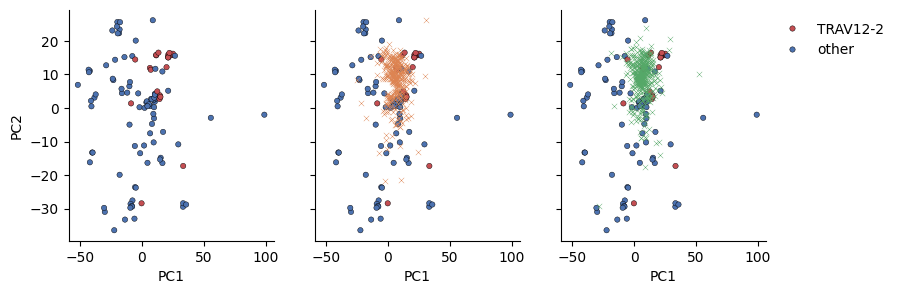

In [6]:
std_pal = sns.color_palette("deep")

df_pca = pd.read_pickle('pca_af3_conf.pkl')
df_pca_exp = df_pca[df_pca['batch'] == 'exp']
df_pca_exp['TRAV-bin'] = np.where(df_pca_exp['TRAV'] == 'TRAV12-2', 'TRAV12-2', 'other')

fig, axes = plt.subplots(1, 3, figsize=(9,3), sharex=True, sharey=True)

ax = axes[0]
sns.scatterplot(df_pca_exp, x='PC1', y='PC2', hue='TRAV-bin', ax=ax, edgecolor='black', s=15, palette={'other': std_pal[0], 'TRAV12-2': std_pal[3]})
ax.legend([],[], frameon=False)

batches = ['Public_Data', 'LAU5013']
for cnt, batch in enumerate(batches):
    ax = axes[cnt+1]
    sns.scatterplot(df_pca_exp, x='PC1', y='PC2', hue='TRAV-bin', ax=ax, edgecolor='black', s=15, palette={'other': std_pal[0], 'TRAV12-2': std_pal[3]})

    df_pca_batch = df_pca[df_pca['batch'] == batch]
    sns.scatterplot(df_pca_batch, x='PC1', y='PC2', ax=ax, color=std_pal[cnt+1], s=15, marker='x')
    ax.legend([],[], frameon=False)

axes[2].legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()


/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_60605/132433298.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pca_exp['TRAV-bin'] = np.where(df_pca_exp['TRAV'] == 'TRAV12-2', 'TRAV12-2', 'other')


0.6904761904761905
0.7493540051679587


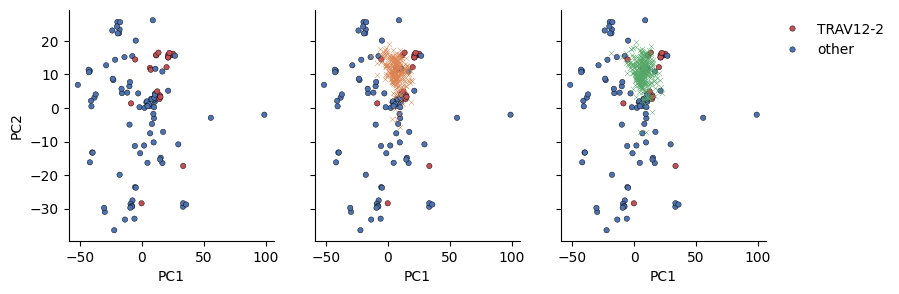

In [ ]:
# ignore non TRAV12-2 models
df_pca = pd.read_pickle('pca_af3_conf.pkl')


df_pca_exp = df_pca[df_pca['batch'] == 'exp']
df_pca_exp['TRAV-bin'] = np.where(df_pca_exp['TRAV'] == 'TRAV12-2', 'TRAV12-2', 'other')

fig, axes = plt.subplots(1, 3, figsize=(9,3), sharex=True, sharey=True)

ax = axes[0]
sns.scatterplot(df_pca_exp, x='PC1', y='PC2', hue='TRAV-bin', ax=ax, edgecolor='black', s=15, palette={'other': std_pal[0], 'TRAV12-2': std_pal[3]})
ax.legend([],[], frameon=False)

batches = ['Public_Data', 'LAU5013']
for cnt, batch in enumerate(batches):
    ax = axes[cnt+1]
    sns.scatterplot(df_pca_exp, x='PC1', y='PC2', hue='TRAV-bin', ax=ax, edgecolor='black', s=15, palette={'other': std_pal[0], 'TRAV12-2': std_pal[3]})

    df_pca_batch = df_pca[df_pca['batch'] == batch]
    before = len(df_pca_batch)
    df_pca_batch = df_pca_batch[df_pca_batch['TRAV'] == 'TRAV12-2']
    after = len(df_pca_batch)
    print(after/before)
    sns.scatterplot(df_pca_batch, x='PC1', y='PC2', ax=ax, color=std_pal[cnt+1], s=15, marker='x')
    ax.legend([],[], frameon=False)

axes[2].legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()


/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95082/917576800.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pca_exp['TRAV-bin'] = np.where(df_pca_exp['TRAV'] == 'TRAV12-2', 'TRAV12-2', 'other')


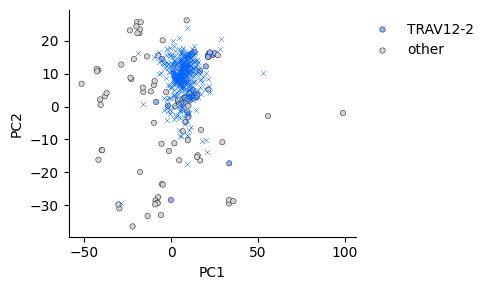

In [23]:
df_pca = pd.read_pickle('pca_af3_conf.pkl')
df_pca_exp = df_pca[df_pca['batch'] == 'exp']
df_pca_exp['TRAV-bin'] = np.where(df_pca_exp['TRAV'] == 'TRAV12-2', 'TRAV12-2', 'other')

df_pca_batch = df_pca[df_pca['batch'] == 'LAU5013']

fig, ax = plt.subplots(1, 1, figsize=(5,3), tight_layout=True)

sns.scatterplot(df_pca_exp, x='PC1', y='PC2', hue='TRAV-bin', ax=ax, edgecolor='black', s=15, palette={'other': "lightgrey", 'TRAV12-2': "#8EB2FF"})
sns.scatterplot(df_pca_batch, x='PC1', y='PC2', ax=ax, color="#0365FF", s=15, marker='x')

ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()
plt.savefig('/Users/roessner/Downloads/output.png', dpi=500)

## Test different features

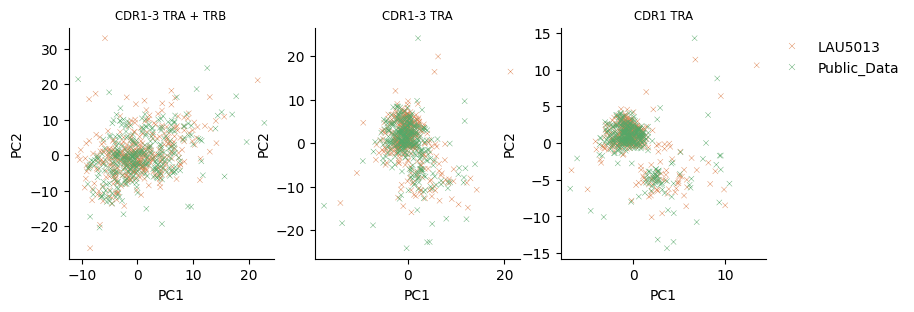

In [ ]:
topdir = 'data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

df = pd.read_pickle('coord_matrix.pkl')
df = df[df['batch'] != 'exp']

# remove unreliable AF3 models
threshold = 0.5

for batch in batches:
    batch_short = batch.split('/')[0]
    csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
    df_af3_conf = pd.read_csv(csv_file)
    exclude_ids = df_af3_conf.loc[df_af3_conf['AF3_iptm_pair_mean'] < threshold, 'id'].tolist()
    df = df[~((df['batch'] == batch_short) & (df['PDB'].isin(exclude_ids)))]

coord_matrix = df.iloc[:,8:].to_numpy()

# select different subsets of coordinates
with open("min_cdr_lengths.pkl", "rb") as f:
    min_cdr_lengths = pickle.load(f)


selections = {'CDR1-3 TRA + TRB' : 3*sum(v for chain in min_cdr_lengths.values() for v in chain.values()),
              'CDR1-3 TRA' : 3*sum(min_cdr_lengths['TRA'].values()),
              'CDR1 TRA' : 3*min_cdr_lengths['TRA']['cdr1']}

fig, axes = plt.subplots(1, 3, figsize=(9,3))

for cnt, (label, limit) in enumerate(selections.items()):
    ax = axes[cnt]

    sel_coord_matrix = coord_matrix[:,:limit]
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(sel_coord_matrix)

    df_pca = df.copy()
    df_pca = df_pca[['PDB', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'batch']]
    df_pca['PC1'] = pcs[:,0]
    df_pca['PC2'] = pcs[:,1]

    # exclude weirdos
    weirdos = ['tcr2669', 'tcr0099', 'tcr1145']
    df_pca = df_pca[~((df_pca['PDB'].isin(weirdos)) & (df_pca['batch'] == 'LAU5013'))]

    sns.scatterplot(df_pca, x='PC1', y='PC2', hue='batch', ax=ax, s=15, marker='x', palette={'LAU5013': std_pal[1], 'Public_Data': std_pal[2]})
    ax.set_title(label, fontsize='small')
    ax.legend([],[], frameon=False)

    if label == 'CDR1 TRA':
        df_pca.to_pickle('pca_CDR1A.pkl')

axes[2].legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()


# UMAP

In [5]:
# umap_env
import glob
import os

import pandas as pd
import pickle
import numpy as np

import umap

import matplotlib.pyplot as plt
import seaborn as sns


/Users/roessner/miniconda3/envs/umap_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


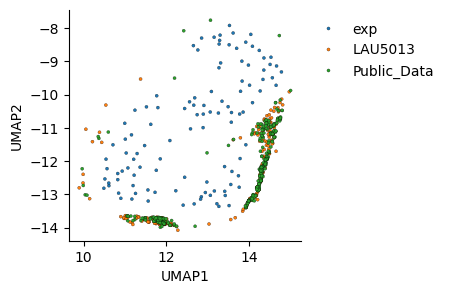

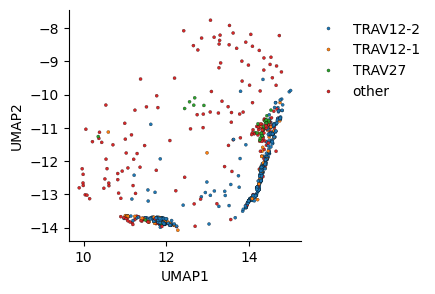

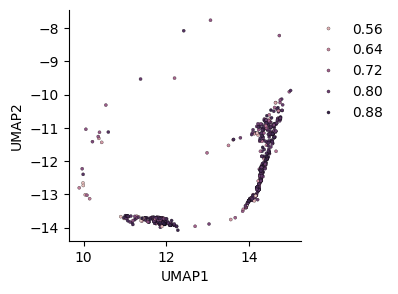

In [ ]:
# umap
df = pd.read_pickle('coord_matrix.pkl')
lst = ['TRAV12-2', 'TRAV12-1', 'TRAV27']
df['TRAV-anno'] = np.where(df['TRAV'].isin(lst), df['TRAV'], 'other')

topdir = 'data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

# remove unreliable AF3 models
threshold = 0.5

lst=[]
for batch in batches:
    batch_short = batch.split('/')[0]
    csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
    df_af3_conf = pd.read_csv(csv_file)
    exclude_ids = df_af3_conf.loc[df_af3_conf['AF3_iptm_pair_mean'] < threshold, 'id'].tolist()
    df = df[~((df['batch'] == batch_short) & (df['PDB'].isin(exclude_ids)))]
    
    df_af3_anno = df_af3_conf[['id', 'AF3_iptm_pair_mean']]
    df_af3_anno['batch'] = batch_short
    lst.append(df_af3_anno)

df_af3_anno = pd.concat(lst)
df_af3_anno = df_af3_anno.rename(columns={'id':'PDB'})

# learn space based on experimental structures
df_exp = df[df['batch'] == 'exp']
coord_matrix_exp = df_exp.iloc[:,8:-1].to_numpy()

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding_exp = umap_model.fit_transform(coord_matrix_exp)

# project AF3-models (YF-epitope) into experimental space
df_af3 = df[df['batch'] != 'exp']
coord_matrix_af3 = df_af3.iloc[:,8:-1].to_numpy()
embedding_af3 = umap_model.transform(coord_matrix_af3)

embedding = np.vstack([embedding_exp, embedding_af3])

df_pca = pd.DataFrame()
df_pca['UMAP1'] = embedding[:,0]
df_pca['UMAP2'] = embedding[:,1]
df_pca['PDB'] = df['PDB'].values
df_pca["PDB"] = df_pca["PDB"].apply(lambda x: os.path.basename(x).split('.')[0])
df_pca['batch'] = df['batch'].values
df_pca['TRAV-anno'] = df['TRAV-anno'].values

df_pca = pd.merge(df_pca, df_af3_anno, how='left', on=['PDB', 'batch'])

fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df_pca, x='UMAP1', y='UMAP2', hue='batch', ax=ax, edgecolor='black', s=5)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()

order = ['TRAV12-2', 'TRAV12-1', 'TRAV27', 'other']
df_pca['TRAV-anno'] = pd.Categorical(df_pca['TRAV-anno'], categories=order, ordered=True)

fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df_pca, x='UMAP1', y='UMAP2', hue='TRAV-anno', ax=ax, edgecolor='black', s=5)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()

fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df_pca, x='UMAP1', y='UMAP2', hue='AF3_iptm_pair_mean', ax=ax, edgecolor='black', s=5)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()


/Users/roessner/miniconda3/envs/umap_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


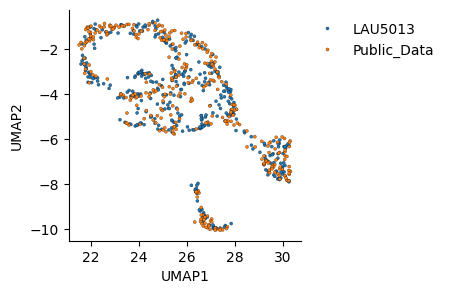

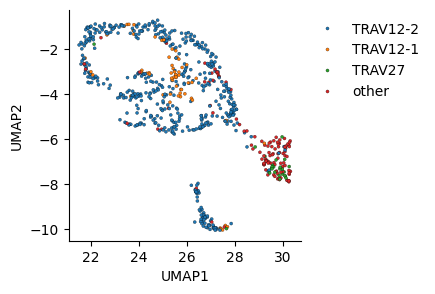

In [ ]:
# umap (exclude experimental structures)
df = pd.read_pickle('coord_matrix.pkl')
lst = ['TRAV12-2', 'TRAV12-1', 'TRAV27']
df['TRAV-anno'] = np.where(df['TRAV'].isin(lst), df['TRAV'], 'other')

topdir = 'data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

# remove unreliable AF3 models
threshold = 0.5

for batch in batches:
    batch_short = batch.split('/')[0]
    csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
    df_af3_conf = pd.read_csv(csv_file)
    exclude_ids = df_af3_conf.loc[df_af3_conf['AF3_iptm_pair_mean'] < threshold, 'id'].tolist()
    df = df[~((df['batch'] == batch_short) & (df['PDB'].isin(exclude_ids)))]

# exclude experimental structures  
df = df[df['batch'] != 'exp']
coord_matrix = df.iloc[:,8:-1].to_numpy()

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding = umap_model.fit_transform(coord_matrix)

df_pca = pd.DataFrame()
df_pca['UMAP1'] = embedding[:,0]
df_pca['UMAP2'] = embedding[:,1]
df_pca['PDB'] = df['PDB'].values
df_pca["PDB"] = df_pca["PDB"].apply(lambda x: os.path.basename(x).split('.')[0])
df_pca['batch'] = df['batch'].values
df_pca['TRAV-anno'] = df['TRAV-anno'].values
df_pca.to_csv('cdr_umap.csv', index=False)

fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df_pca, x='UMAP1', y='UMAP2', hue='batch', ax=ax, edgecolor='black', s=5)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()

order = ['TRAV12-2', 'TRAV12-1', 'TRAV27', 'other']
df_pca['TRAV-anno'] = pd.Categorical(df_pca['TRAV-anno'], categories=order, ordered=True)

fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df_pca, x='UMAP1', y='UMAP2', hue='TRAV-anno', ax=ax, edgecolor='black', s=5)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()




UMAP1        24.527843
UMAP2        -3.162482
PDB            tcr0089
batch          LAU5013
TRAV-anno     TRAV12-2
cluster              0
Name: 21, dtype: object
UMAP1        29.24066
UMAP2       -6.263823
PDB           tcr0166
batch         LAU5013
TRAV-anno       other
cluster             1
Name: 11, dtype: object
UMAP1        26.76559
UMAP2       -9.527072
PDB           tcr1667
batch         LAU5013
TRAV-anno    TRAV12-2
cluster             2
Name: 22, dtype: object


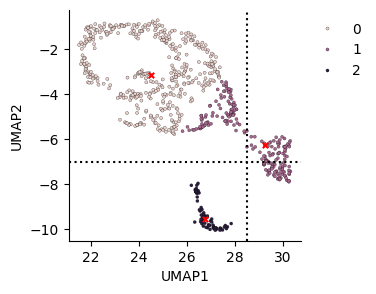

In [13]:
# get cluster models
df = pd.read_csv('cdr_umap.csv')
umaps = df[['UMAP1', 'UMAP2']].values

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)  
labels = kmeans.fit_predict(umaps)

df['cluster'] = labels

fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df, x='UMAP1', y='UMAP2', hue='cluster', ax=ax, edgecolor='black', s=5, legend=True)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()

# get medoid (=densest actual point in each cluster)
batches_anno = {
    'LAU5013' : 'data_julien/LAU5013/YF_LAU5013_sc_WT',
    'Public_Data' : 'data_julien/Public_Data/YF_public_pairedData_20251010'
}

if os.path.exists('YF_umap_clusters'):
        shutil.rmtree('YF_umap_clusters')
os.makedirs('YF_umap_clusters')

densest_points = []
for cluster in range(3):
    
    df_cluster = df.loc[df['cluster'] == cluster].reset_index(drop=True)
    cluster_points = df_cluster[['UMAP1', 'UMAP2']].values
    
    dists = pairwise_distances(cluster_points) # pairwise distances within cluster
    mean_dists = dists.mean(axis=1) # mean distance to all other points
    medoid_idx = np.argmin(mean_dists) # index of medoid
    densest_points.append(cluster_points[medoid_idx])

    closest_model = df_cluster.loc[medoid_idx]
    print(closest_model)
    
    src_file = f"{batches_anno[closest_model['batch']]}/model_pdb_align_exp/{closest_model['PDB']}.pdb"
    dst_file = f"YF_umap_clusters/cluster{cluster}_{closest_model['PDB']}_{closest_model['batch']}.pdb"
    shutil.copy(src_file, dst_file)

densest_points = np.array(densest_points)
ax.scatter(densest_points[:,0], densest_points[:,1], c='red', s=15, marker='x')
ax.axhline(-7, color='black', linestyle=':')
ax.axvline(28.5, color='black', linestyle=':')


In [19]:
# extract csv for motifs
df = pd.read_csv('cdr_umap.csv')

# annotate
topdir = 'data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

lst=[]
for batch in batches:
    batch_short = batch.split('/')[0]
    csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
    df_anno = pd.read_csv(csv_file)[['id', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr3_TRA', 'cdr3_TRB']]
    df_anno = df_anno.rename(columns={'id':'PDB'})
    df_anno['batch'] = batch_short
    lst.append(df_anno)

df_anno = pd.concat(lst)
df = pd.merge(df, df_anno, on=['PDB', 'batch'])

for i in range(3):
    if i == 0:
        df_cluster = df[(df['UMAP1'] < 28.5) & (df['UMAP2'] > -7)]
    elif i == 1:
         df_cluster = df[df['UMAP1'] > 28.5]
    else:
        df_cluster = df[(df['UMAP1'] < 28.5) & (df['UMAP2'] < -7)]

    df_cluster.to_csv(f'umap_cluster{i}.csv', index=False)

## Clustering on CDR1A PCA

PDB         tcr0673
TRAV       TRAV12-2
TRAJ         TRAJ44
TRBV        TRBV5-4
TRBJ        TRBJ2-7
batch       LAU5013
PC1       -0.463898
PC2        1.158558
cluster           0
Name: 107, dtype: object
PDB            tcr0302
TRAV            TRAV27
TRAJ            TRAJ58
TRBV             TRBV9
TRBJ           TRBJ2-1
batch      Public_Data
PC1           2.800949
PC2           -4.99519
cluster              1
Name: 105, dtype: object


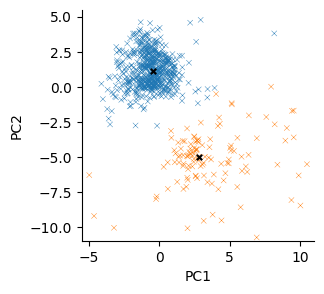

In [ ]:
df_pca = pd.read_pickle('pca_CDR1A.pkl')
pcs = df_pca[['PC1', 'PC2']].values

# KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)  
labels = kmeans.fit_predict(pcs)

df_pca['cluster'] = labels
df_pca['cluster'] = df_pca['cluster'].map({0: 1, 1: 0})
df_pca.to_pickle('pca_CDR1A_cluster.pkl')

fig, ax = plt.subplots(1, 1, figsize=(3,3))
sns.scatterplot(df_pca, x='PC1', y='PC2', hue='cluster', ax=ax, s=15, marker='x')
ax.set_xlim(-5.5, 11)
ax.set_ylim(-11, 5.5)
ax.legend([],[], frameon=False)
sns.despine()

# extract models
batches_anno = {
    'LAU5013' : 'data_julien/LAU5013/YF_LAU5013_sc_WT',
    'Public_Data' : 'data_julien/Public_Data/YF_public_pairedData_20251010'
}

if os.path.exists('YF_CDR1A_clusters'):
        shutil.rmtree('YF_CDR1A_clusters')

densest_points = []
for cluster in range(2):
    outdir = f'YF_CDR1A_clusters/{cluster}'
    os.makedirs(outdir, exist_ok=True)

    for batch, path in batches_anno.items():
        tmp = df_pca[(df_pca['cluster'] == cluster) & (df_pca['batch'] == batch)]
        ids = tmp['PDB'].values

        for id in ids:
            src_file = f'{path}/model_pdb_align_exp/{id}.pdb'
            dst_file = f'{outdir}/{id}_{batch}.pdb'
            shutil.copy(src_file, dst_file)

    # get medoid (=densest actual point in each cluster)
    df_cluster = df_pca.loc[df_pca['cluster'] == cluster].reset_index(drop=True)

    cluster_points = df_cluster[['PC1', 'PC2']].values
    
    dists = pairwise_distances(cluster_points) # pairwise distances within cluster
    mean_dists = dists.mean(axis=1) # mean distance to all other points
    medoid_idx = np.argmin(mean_dists) # index of medoid
    densest_points.append(cluster_points[medoid_idx])

    closest_model = df_cluster.loc[medoid_idx]
    print(closest_model)
    
    # Copy the corresponding PDB file
    for batch, path in batches_anno.items():
        if closest_model['batch'] == batch:
            src_file = f"{path}/model_pdb_align_exp/{closest_model['PDB']}.pdb"
            dst_file = f"YF_CDR1A_clusters/cluster_{cluster}_{closest_model['PDB']}_{batch}_centroid.pdb"
            shutil.copy(src_file, dst_file)
    

densest_points = np.array(densest_points)
ax.scatter(densest_points[:,0], densest_points[:,1], c='black', s=15, marker='x')

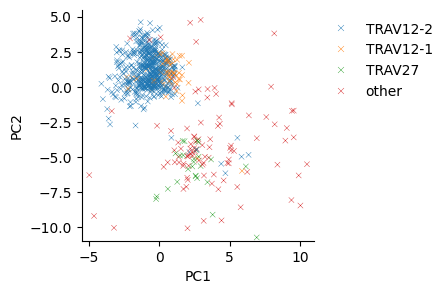

In [50]:
# color by TRAV
df_pca = pd.read_pickle('pca_CDR1A.pkl')

lst = ['TRAV12-2', 'TRAV12-1', 'TRAV27']
df_pca['tmp'] = np.where(df_pca['TRAV'].isin(lst), df_pca['TRAV'], 'other')
order = ['TRAV12-2', 'TRAV12-1', 'TRAV27', 'other']
df_pca['tmp'] = pd.Categorical(df_pca['tmp'], categories=order, ordered=True)

fig, ax = plt.subplots(1, 1, figsize=(3,3))
sns.scatterplot(df_pca, x='PC1', y='PC2', hue='tmp', ax=ax, s=15, marker='x')
ax.legend(frameon=False, bbox_to_anchor=(1,1), loc='upper left')
ax.set_xlim(-5.5, 11)
ax.set_ylim(-11, 5.5)
sns.despine()

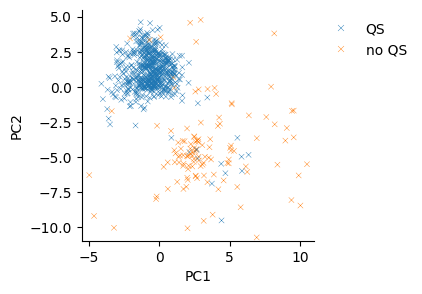

In [51]:
# color by QS in CDR1a
df_pca = pd.read_pickle('pca_CDR1A.pkl')

# annotate CDR1a sequence
batches_anno = {
    'exp' : 'tcr_pdbs_chains_david_mhci_fixed.csv',
    'LAU5013' : 'data_julien/LAU5013/YF_LAU5013_sc_WT/YF_LAU5013_sc_WT_AF3_anno.csv',
    'Public_Data' : 'data_julien/Public_Data/YF_public_pairedData_20251010/YF_public_pairedData_20251010_AF3_anno.csv'
}

lst=[]
for batch, csv_file in batches_anno.items():
    if batch == 'exp':
        df_anno = pd.read_csv(csv_file, sep=';')
    else:
        df_anno = pd.read_csv(csv_file)
        df_anno = df_anno.rename(columns={'id':'PDB', 'cdr1_TRA':'CDR1A'})

    df_anno = df_anno[['PDB', 'CDR1A']]
    df_anno['CDR1A'] = df_anno['CDR1A'].str.upper()

    df_anno['batch'] = batch
    lst.append(df_anno)

anno = pd.concat(lst)

df_merged = pd.merge(anno, df_pca, on=['PDB', 'batch'])
df_merged['QS'] = np.where(df_merged['CDR1A'].str.contains('QS', na=False), 'QS', 'no QS')

fig, ax = plt.subplots(1, 1, figsize=(3,3))
sns.scatterplot(df_merged, x='PC1', y='PC2', hue='QS', ax=ax, s=15, marker='x')
ax.legend(frameon=False, bbox_to_anchor=(1,1), loc='upper left')
ax.set_xlim(-5.5, 11)
ax.set_ylim(-11, 5.5)
sns.despine()

# Extract dataframes for motif calculation

In [ ]:
# curate dataframe for motif extraction
df = pd.read_pickle('pca_CDR1A_cluster.pkl')

topdir = 'data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

lst=[]
for batch in batches:
    batch_short = batch.split('/')[0]
    
    # CDRs annotated with tcr_cdr_annotation.R
    csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
    anno = pd.read_csv(csv_file)[['id', 'cdr3_TRA', 'cdr3_TRB']]
    anno = anno.rename(columns={'id':'PDB'})
    anno['batch'] = batch_short
    lst.append(anno)

anno = pd.concat(lst)
df_merged = pd.merge(df, anno, on=['PDB', 'batch'])
df_merged.to_csv("pca_CDR1A_cluster.csv", index=False)

In [ ]:
topdir = 'data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

threshold = 0.5

lst=[]
for batch in batches:
    batch_short = batch.split('/')[0]
    csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
    df = pd.read_csv(csv_file)
    df = df[df["TEMPOproblem"].isna()]
    sel_ids = df.loc[df['AF3_iptm_pair_mean'] < threshold, 'id'].tolist()
    df = df[df['id'].isin(exclude_ids)]
    df = df[['id','TRAV','TRAJ','cdr3_TRA','TRBV','TRBJ','cdr3_TRB','AF3_iptm_pair_mean']]
    df = df.dropna()
    df['batch'] = batch_short
    lst.append(df)

df = pd.concat(lst)
df.to_csv('low_confidence_models.csv', index=False)
print(df)


21
12
40
40
          id          TRAV    TRAJ           cdr3_TRA      TRBV     TRBJ  \
4    tcr0008      TRAV12-2  TRAJ30         CAVGDDKIIF  TRBV20-1  TRBJ2-3   
6    tcr0012       TRAV1-2  TRAJ12       CAVMDSSYKLIF   TRBV6-1  TRBJ2-1   
16   tcr0031      TRAV12-2  TRAJ34        CAVGTTDKLIF   TRBV7-6  TRBJ2-7   
34   tcr0063      TRAV12-2  TRAJ49         CAVDGNQFYF    TRBV27  TRBJ2-7   
61   tcr0113      TRAV12-2  TRAJ11        CALSGYSTLTF    TRBV15  TRBJ1-6   
88   tcr0164        TRAV27  TRAJ15      CAGADQAGTALIF     TRBV9  TRBJ2-1   
89   tcr0166    TRAV29/DV5  TRAJ30        CAASADDKIIF   TRBV5-6  TRBJ2-2   
106  tcr0197      TRAV12-2  TRAJ30         CAGGDDKIIF  TRBV12-3  TRBJ2-7   
118  tcr0216      TRAV12-2  TRAJ30         CAPGDDKIIF     TRBV9  TRBJ2-1   
122  tcr0223        TRAV10  TRAJ35      CVAGAGFGNVLHC   TRBV4-2  TRBJ2-7   
127  tcr0233        TRAV17  TRAJ20      CATDPAGDYKLSF   TRBV4-1  TRBJ2-7   
196  tcr0363      TRAV12-2  TRAJ13      CALYSGGYQKVTF   TRBV6-5  TRBJ1-3   


         PDB        TRAV    TRAJ        cdr3_TRA     TRBV     TRBJ  \
0       1ao7    TRAV12-2  TRAJ24     AVttdswgKLQ  TRBV6-5  TRBJ2-7   
1       1bd2  TRAV29/DV5  TRAJ54      AAmegaqkLV  TRBV6-5  TRBJ2-7   
2       1mi5    TRAV26-2  TRAJ52  ILPlaggstyGKLT  TRBV7-8  TRBJ2-7   
3       1qrn    TRAV12-2  TRAJ24     AVttdswgkLQ  TRBV6-5  TRBJ2-7   
4       1qse    TRAV12-2  TRAJ24     AVttdswgKLQ  TRBV6-5  TRBJ2-7   
..       ...         ...     ...             ...      ...      ...   
930  tcr0385    TRAV12-2  TRAJ31      CAGANARLMF  TRBV7-6  TRBJ2-2   
931  tcr0386      TRAV27  TRAJ30   CAGVLSRDDKIIF  TRBV7-6  TRBJ1-2   
932  tcr0387    TRAV12-2  TRAJ31      CAVTGARLMF   TRBV19  TRBJ2-7   
933  tcr0388    TRAV12-2  TRAJ27      CAVSAGKSTF  TRBV6-1  TRBJ2-7   
934  tcr0389      TRAV16   TRAJ4    CALSGGYNKLIF  TRBV4-3  TRBJ1-2   

              cdr3_TRB        batch          0          1  ...         95  \
0       ASrPglaggrpEQY          exp  91.323997  18.611000  ... -13.081000   
1    

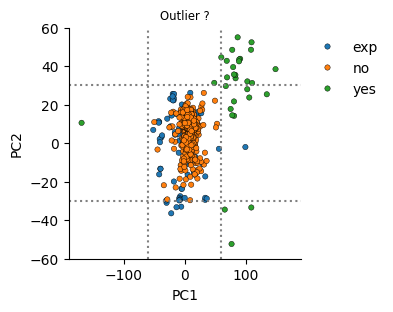

In [79]:
df = pd.read_pickle('coord_matrix.pkl')

# learn space based on experimental structures
df_exp = df[df['batch'] == 'exp']
coord_matrix_exp = df_exp.iloc[:,8:].to_numpy()
pca = PCA(n_components=2)
pcs_exp = pca.fit_transform(coord_matrix_exp)

# project AF3-models (YF-epitope) into experimental space
df_af3 = df[df['batch'] != 'exp']
coord_matrix_af3 = df_af3.iloc[:,8:].to_numpy()
pcs_af3 = pca.transform(coord_matrix_af3)

pcs = np.concatenate([pcs_exp, pcs_af3])

df_pca = df.copy()
df_pca['PC1'] = pcs[:,0]
df_pca['PC2'] = pcs[:,1]
df_pca['PDB'] = df['PDB'].values
df_pca["PDB"] = df_pca["PDB"].apply(lambda x: os.path.basename(x).split('.')[0])
df_pca['batch'] = df['batch'].values
df_pca['outlier'] = np.where(
    df_pca['batch'] == 'exp',
    'exp',
    np.where(
        (df_pca['PC1'] > -60) & (df_pca['PC1'] < 60) &
        (df_pca['PC2'] > -30) & (df_pca['PC2'] < 30),
        'no',
        'yes'
    )
)


fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df_pca, x='PC1', y='PC2', hue='outlier', ax=ax, edgecolor='black', s=15)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
ax.set_xlim(-190, 190)
ax.set_ylim(-60, 60)
ax.axvline(-60, color='grey', linestyle=':')
ax.axvline(60, color='grey', linestyle=':')
ax.axhline(-30, color='grey', linestyle=':')
ax.axhline(30, color='grey', linestyle=':')
ax.set_title('Outlier ?', fontsize='small')
sns.despine()
print(df_pca)
df_pca = df_pca[['PDB', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB', 'batch', 'PC1', 'PC2', 'outlier']]
df_pca.to_csv('outlier_models.csv', index=False)

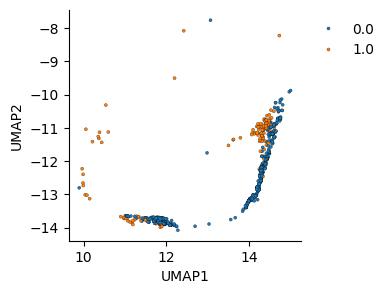

In [12]:
# annotate umap by cdr1a clusters
df_umap = pd.read_pickle('cdr_umap.pkl')
df_umap = df_umap.drop(columns=['TRAV-anno'])

df_pca = pd.read_pickle('pca_CDR1A_cluster.pkl')[['PDB', 'batch', 'cluster']]
df = pd.merge(df_umap, df_pca, how='left', on=['PDB', 'batch'])

#order = ['TRAV12-2', 'TRAV12-1', 'TRAV27', 'other']
#df_pca['TRAV-anno'] = pd.Categorical(df_pca['TRAV-anno'], categories=order, ordered=True)

fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df, x='UMAP1', y='UMAP2', hue='cluster', ax=ax, edgecolor='black', s=5)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()